# <center> Machine Learning in Computational Biology - Term Project </center>

## <center> Task B.2 </center>

### <center> Differential Pathway Analysis: Responders vs. Non-responders </center>
---


# Libraries & Paths

In [1]:
import random, os, warnings
warnings.filterwarnings("ignore")
#######################################################################

import numpy as np
import pandas as pd
import scanpy as sc
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import statsmodels.formula.api as smf #[14]
from statsmodels.stats.multitest import multipletests #[13]
from statsmodels.tools.sm_exceptions import ConvergenceWarning
#######################################################################

# Set seed --> reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
#######################################################################

# Path of input & output data
data_dir = Path('../data')
output_dir = Path('../outputs')
output_dir.mkdir(parents=True, exist_ok=True)
figures_dir = Path('../figures')
figures_dir.mkdir(parents=True, exist_ok=True)
results_dir = output_dir / 'differential_pathway_analysis'
results_dir.mkdir(parents=True, exist_ok=True)
pathway_anndata = output_dir / 'filtered_anndata_pathways.h5ad'
#######################################################################

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
print('Loaded')

Loaded


# Loading the Pathway-Extended AnnData

In [2]:
# Checking once more the data, Step 
adata = sc.read_h5ad(pathway_anndata)
pathway_cols = [ c for c in adata.obs.columns if str(c).startswith('PROGENy_')]

if len(pathway_cols) != 14:
    raise ValueError(f"Expected 14 PROGENy pathway columns, but found {len(pathway_cols)}: {pathway_cols}")

required_cols = {'patient_id', 'patient_timepoint', 'timepoint'}
missing_required = required_cols - set(adata.obs.columns)
if missing_required:
    print(f"Missing required columns in adata.obs: {missing_required}")

response_column = 'response_label' # str choice of response

print(f"AnnData shape : {adata.shape}")
print(f"PROGENy pathways : {len(pathway_cols)}")
print(f"Response column : {response_column}")
print(f"Unique patients : {adata.obs['patient_id'].nunique()}")
print(f"Unique samples : {adata.obs['patient_timepoint'].nunique()}")

AnnData shape : (16291, 10019)
PROGENy pathways : 14
Response column : response_label
Unique patients : 32
Unique samples : 48


# Cell to Sample -->  Aggregating Pathway Scores to Sample Level

In [3]:
# Sanity check:
# Before moving from cell-level to sample-level pathway activity, we are checking that all cells
# belonging to the same biological sample have consistent patient, timepoint and response metadata.

# Grouping cells according to their biological sample
grouped = adata.obs.groupby('patient_timepoint', observed=True)

# Checking that each biological sample corresponds to only one patient,
# one treatment timepoint and one response label
consistency = grouped.agg(n_patient_ids=('patient_id', 'nunique'),
                          n_timepoints=('timepoint', 'nunique'),
                          n_response_labels=(response_column, 'nunique'))


if not (consistency == 1).all().all():
    raise ValueError('At least one biological sample has inconsistent metadata across its cells.')

# Calculation of one mean pathway score per biological sample
sample_pathway_df = grouped[pathway_cols].mean()

# Keeping one metadata row for each biological sample
sample_meta = grouped.agg(patient_id=('patient_id', 'first'),timepoint=('timepoint', 'first'),
                          response_label=(response_column, 'first'),n_cells=('patient_timepoint', 'size'))

# Combining the sample metadata with the mean pathway scores
sample_df = sample_meta.join(sample_pathway_df)


print(f"Biological samples: {sample_df.shape[0]}")
print(f"Unique patients: {sample_df['patient_id'].nunique()}")
print(f"Pathway columns: {len(pathway_cols)}")
print("\nResponse distribution at the sample level:")
print(sample_df['response_label'].value_counts())
print("\nTimepoint distribution at the sample level:")
print(sample_df['timepoint'].value_counts())


display(sample_df.head())
sample_df.shape

Biological samples: 48
Unique patients: 32
Pathway columns: 14

Response distribution at the sample level:
response_label
Non-responder    31
Responder        17
Name: count, dtype: int64

Timepoint distribution at the sample level:
timepoint
Post    29
Pre     19
Name: count, dtype: int64


,patient_id,timepoint,response_label,n_cells,PROGENy_Androgen,PROGENy_EGFR,PROGENy_Estrogen,PROGENy_Hypoxia,PROGENy_JAK-STAT,PROGENy_MAPK,PROGENy_NFkB,PROGENy_PI3K,PROGENy_TGFb,PROGENy_TNFa,PROGENy_Trail,PROGENy_VEGF,PROGENy_WNT,PROGENy_p53
patient_timepoint,,,,,,,,,,,,,,,,,,
Post_P1,P1,Post,Responder,291,-0.267944,1.747697,-0.160309,1.394581,2.182085,-1.484053,-0.261968,1.658277,-0.000630,2.103891,-1.511142,-0.942383,-0.505785,-0.068269
Post_P1_2,P1,Post,Non-responder,353,-0.386763,1.247777,-0.900157,1.787207,3.078653,-2.425725,-0.462121,0.713790,-0.874865,1.860373,-1.123560,-0.810444,-0.288837,0.136242
Post_P2,P2,Post,Non-responder,380,-0.382969,1.911473,-0.806460,1.843982,3.529684,-2.059272,-0.177829,1.236425,-0.242309,2.038291,-1.262688,-0.971504,-0.470309,0.233797
Post_P3,P3,Post,Non-responder,359,-0.201031,1.932871,-0.932481,2.321971,1.862227,-2.118971,0.469641,1.529941,-0.166020,1.917017,-1.449445,-0.767904,-0.275412,0.620521
Post_P3_2,P3,Post,Non-responder,358,-0.096420,2.113912,-0.620120,2.696029,1.500151,-1.706430,1.022150,1.602743,0.053241,1.901994,-1.213543,-0.886301,-0.400128,0.684039


(48, 18)

In [4]:
# Checking patients with repeated samples and patients with mixed response labels
samples_per_patient = sample_df.groupby('patient_id').size().sort_values(ascending=False)
patient_response_counts = sample_df.groupby('patient_id')['response_label'].nunique()

repeated_patients = samples_per_patient[samples_per_patient > 1].index.tolist()
single_sample_patients = samples_per_patient[samples_per_patient == 1].index.tolist()
mixed_patients = patient_response_counts[patient_response_counts > 1].index.tolist()

# Cases with more than one biological sample, either from different treatment timepoints (Pre/Post) 
# or from multiple biopsies collected within the same treatment timepoint (e.g. multiple Post samples).
print(f"Patients with >1 biological sample: {len(repeated_patients)}") 
print(repeated_patients)

print(f"Patients with exactly 1 biological sample: {len(single_sample_patients)}")
print(single_sample_patients)

print(f"Patients with mixed response labels: {len(mixed_patients)}") # Only different timepoints
print(mixed_patients)


Patients with >1 biological sample: 13
['P1', 'P3', 'P28', 'P2', 'P5', 'P6', 'P7', 'P4', 'P12', 'P15', 'P20', 'P8', 'P23']
Patients with exactly 1 biological sample: 19
['P13', 'P11', 'P10', 'P17', 'P16', 'P14', 'P19', 'P21', 'P22', 'P24', 'P18', 'P25', 'P26', 'P27', 'P29', 'P30', 'P31', 'P33', 'P35']
Patients with mixed response labels: 4
['P1', 'P4', 'P5', 'P28']


**Observation:** Reminding that the analysis is performed at the biological-sample level rather than treating the 16,291 cells as independent observations, with the final table containing 48 samples from 32 patients, with 31 Non-responder and 17 Responder samples and 29 Post-treatment versus 19 Pre-treatment samples.

Also, thirteen patients contribute more than one biological sample. Four patients (`P1`, `P4`, `P5` and `P28`) contain samples with different response labels. 

Regarding those patients, they remain in the primary mixed-effects analysis, where repeated measurements are handled through the patient random intercept, but are excluded from the later one-value-per-patient sensitivity analysis.

---
# Primary Differential Analysis: Mixed-Effects Models

*Methodology followed:*

- A separate linear mixed-effects model is fitted for each of the 14 PROGENy pathways, with response and treatment timepoint as fixed effects and a patient-specific random intercept, allowing repeated biological samples from the same patient to remain in the analysis without treating them as fully independent. #[14]

- The response-effect p-values from the 14 pathway models are corrected together using the Benjamini-Hochberg false discovery rate procedure. #[13]

In [5]:
# Mixed-effects model for differential pathway activity.
# The model is fitted separately for each pathway:
# activity ~ response + timepoint + (1 | patient)
############################################################################
# Non-responder is used as the reference response group:
# beta_response > 0 -> higher pathway activity in Responders
# beta_response < 0 -> higher pathway activity in Non-responders
############################################################################
# Pre is used as the reference timepoint:
# beta_timepoint > 0 -> higher pathway activity in Post compared with Pre
# beta_timepoint < 0 -> lower pathway activity in Post compared with Pre
############################################################################
# A random intercept is included for patient_id so that multiple biological
# samples originating from the same patient are not treated as fully independent.
# Like that repeated samples, including multiple biopsies from the same treatment timepoint, remain in the analysis.


def fit_pathway_mixed_model(df, pathway):

    # Keepping only the variables required for the model
    model_df = df[ [pathway, 'response_label', 'timepoint', 'patient_id']].dropna().copy()

    # Using a common outcome name so that the same formula can be applied independently to each of the 14 pathway scores
    model_df = model_df.rename(columns={pathway: 'activity'})

    # Fixed effects:
    # response: main effect of interest
    # timepoint: adjustment for Pre/Post differences
    formula = ("activity ~ " 
               "C(response_label, Treatment(reference='Non-responder')) + "
               "C(timepoint, Treatment(reference='Pre'))")
    
    response_term = ("C(response_label, Treatment(reference='Non-responder'))[T.Responder]")

    timepoint_term = ("C(timepoint, Treatment(reference='Pre'))[T.Post]")

    # Random intercept for patient_id accounts for the dependence between repeated biological samples originating from the same patient.
    model = smf.mixedlm(formula,data=model_df,groups=model_df['patient_id'],re_formula='1')

    # Trying multiple optimizers for numerical robustness.
    # Convergence warnings are recorded.
    fit = None
    used_method = None
    last_error = None
    convergence_warnings = []

    for method in ['lbfgs', 'bfgs', 'powell']:
        try:
            with warnings.catch_warnings(record=True) as caught:
                warnings.simplefilter("always", ConvergenceWarning)
                candidate = model.fit(reml=False, method=method,maxiter=2000,disp=False)

            current_warnings = [str(w.message) for w in caught if issubclass(w.category, ConvergenceWarning)]
            fit = candidate
            used_method = method
            convergence_warnings = current_warnings

            # Stopping once a converged solution has been obtained
            if bool(candidate.converged):
                break

        except Exception as exc:
            last_error = str(exc)


    # A fitted object may exist even when none of the optimizers converged, a result should not be treated as a reliable final model.
    if fit is None:
        raise RuntimeError(f"Mixed model failed for {pathway}. Last error: {last_error}")

    ci = fit.conf_int()

    # Response effect--> Responder compared with Non-responder
    response_beta = float(fit.params[response_term])
    response_p = float(fit.pvalues[response_term])
    response_ci_low = float(ci.loc[response_term, 0])
    response_ci_high = float(ci.loc[response_term, 1])

    # Timepoint effect--> Post compared with Pre
    timepoint_beta = (float(fit.params[timepoint_term]) if timepoint_term in fit.params else np.nan)
    timepoint_p = (float(fit.pvalues[timepoint_term]) if timepoint_term in fit.pvalues else np.nan)

    # Here the estimation of the variance of the patient-specific random intercept occurs, where
    # values close to zero may indicate that little additional variability
    # is attributed to patient-to-patient baseline differences.
    random_intercept_var = (float(fit.cov_re.iloc[0, 0]) if fit.cov_re.shape[0] > 0 else np.nan)

    return {'pathway': pathway.replace('PROGENy_', ''),
            'n_samples': int(model_df.shape[0]),
            'n_patients': int(model_df['patient_id'].nunique()),
            'beta_response_R_vs_NR': response_beta,
            'ci95_low': response_ci_low,
            'ci95_high': response_ci_high,
            'p_value_response': response_p,
            'beta_timepoint_Post_vs_Pre': timepoint_beta,
            'p_value_timepoint': timepoint_p,
            'random_intercept_variance': random_intercept_var,
            'converged': bool(fit.converged),
            'optimizer': used_method,
            'convergence_warning': ("; ".join(convergence_warnings) if convergence_warnings else "None")
            }

In [6]:
# Fitting the mixed-effects model for all 14 pathways
mixed_rows = [fit_pathway_mixed_model(sample_df, pathway)for pathway in pathway_cols]
mixed_results = pd.DataFrame(mixed_rows)


# Benjamini-Hochberg FDR correction across the 14 response-effect p-values
reject, p_fdr, _, _ = multipletests(mixed_results['p_value_response'],alpha=0.05,method='fdr_bh')
mixed_results['p_fdr_bh_response'] = p_fdr
mixed_results['significant_fdr_0.05'] = reject


# Direction of the response effect
mixed_results['direction'] = np.select([mixed_results['beta_response_R_vs_NR'] > 0,
                                        mixed_results['beta_response_R_vs_NR'] < 0],
                                        ['Higher in Responders', 
                                         'Higher in Non-responders'],
                                        default='No directional difference')


# Flagging models with a patient-level random-effect variance very close to zero
mixed_results['near_zero_random_effect'] = (mixed_results['random_intercept_variance'] < 1e-6)


# Compact model-quality summary
mixed_results['model_qc'] = np.select([~mixed_results['converged'],mixed_results['near_zero_random_effect']],
                                      ['Did not converge',
                                       'Converged - random-effect variance near zero'],
                                      default='Converged')


# Ranking pathways according to the FDR-adjusted response effect
mixed_results = (mixed_results.sort_values('p_fdr_bh_response').reset_index(drop=True))

display(mixed_results)

,pathway,n_samples,n_patients,beta_response_R_vs_NR,ci95_low,ci95_high,p_value_response,beta_timepoint_Post_vs_Pre,p_value_timepoint,random_intercept_variance,converged,optimizer,convergence_warning,p_fdr_bh_response,significant_fdr_0.05,direction,near_zero_random_effect,model_qc
0,EGFR,48,32,-0.486141,-0.709286,-0.262996,0.000020,0.068299,0.501405,3.709301e-02,True,lbfgs,None,0.000141,True,Higher in Non-responders,False,Converged
1,JAK-STAT,48,32,-1.881732,-2.765932,-0.997532,0.000030,-0.716381,0.057972,1.130692e+00,True,bfgs,None,0.000141,True,Higher in Non-responders,False,Converged
2,MAPK,48,32,0.468923,0.250819,0.687026,0.000025,-0.110841,0.226674,5.766648e-02,True,lbfgs,None,0.000141,True,Higher in Responders,False,Converged
3,WNT,48,32,-0.202681,-0.331404,-0.073959,0.002028,-0.025125,0.654677,1.514581e-02,True,bfgs,None,0.007098,True,Higher in Non-responders,False,Converged
4,TNFa,48,32,-0.197728,-0.355816,-0.039640,0.014229,0.050001,0.467048,3.109424e-02,True,bfgs,None,0.039842,True,Higher in Non-responders,False,Converged
5,Estrogen,48,32,0.149694,0.023835,0.275553,0.019746,-0.079911,0.143981,2.243983e-02,True,bfgs,None,0.046075,True,Higher in Responders,False,Converged
6,PI3K,48,32,-0.265903,-0.496135,-0.035671,0.023597,0.021414,0.839247,1.684649e-02,True,bfgs,None,0.047194,True,Higher in Non-responders,False,Converged
7,p53,48,32,0.227655,0.013784,0.441525,0.036953,-0.065119,0.522284,2.165770e-02,True,bfgs,None,0.057482,False,Higher in Responders,False,Converged
8,Trail,48,32,0.207788,0.012696,0.402880,0.036842,0.003863,0.964059,4.327515e-02,True,bfgs,None,0.057482,False,Higher in Responders,False,Converged
9,Androgen,48,32,0.118168,-0.011325,0.247662,0.073687,-0.083813,0.269671,3.469709e-10,True,lbfgs,The MLE may be on the boundary of the paramete...,0.103162,False,Higher in Responders,True,Converged - random-effect variance near zero


In [7]:
mixed_results[['pathway', 'random_intercept_variance']].sort_values('random_intercept_variance')

,pathway,random_intercept_variance
9,Androgen,3.469709e-10
3,WNT,1.514581e-02
10,VEGF,1.634631e-02
6,PI3K,1.684649e-02
11,TGFb,1.924891e-02
7,p53,2.165770e-02
5,Estrogen,2.243983e-02
4,TNFa,3.109424e-02
0,EGFR,3.709301e-02
8,Trail,4.327515e-02


In [8]:
mixed_results.to_csv(results_dir / 'mixed_effects_differential_pathways.csv', index=False)

In [9]:
# Summary of mixed-model convergence and response-associated pathways
print(f"Converged models: {mixed_results['converged'].sum()} / {len(mixed_results)}")
print(f"Models with near-zero random-effect variance: {mixed_results['near_zero_random_effect'].sum()} / {len(mixed_results)}")


# Number of pathways significant for the response effect after FDR correction
n_significant_mixed = int(mixed_results['significant_fdr_0.05'].sum())
print(f"Pathways significant for the response effect at FDR < 0.05: {n_significant_mixed} / {len(mixed_results)}")


# Displaying the significant pathways and their response-effect estimates
if n_significant_mixed > 0:
    display(mixed_results.loc[mixed_results['significant_fdr_0.05'],
                              ['pathway','beta_response_R_vs_NR','ci95_low',
                               'ci95_high','p_value_response','p_fdr_bh_response',
                               'direction','model_qc']])

Converged models: 14 / 14
Models with near-zero random-effect variance: 1 / 14
Pathways significant for the response effect at FDR < 0.05: 7 / 14


,pathway,beta_response_R_vs_NR,ci95_low,ci95_high,p_value_response,p_fdr_bh_response,direction,model_qc
0,EGFR,-0.486141,-0.709286,-0.262996,0.000020,0.000141,Higher in Non-responders,Converged
1,JAK-STAT,-1.881732,-2.765932,-0.997532,0.000030,0.000141,Higher in Non-responders,Converged
2,MAPK,0.468923,0.250819,0.687026,0.000025,0.000141,Higher in Responders,Converged
3,WNT,-0.202681,-0.331404,-0.073959,0.002028,0.007098,Higher in Non-responders,Converged
4,TNFa,-0.197728,-0.355816,-0.039640,0.014229,0.039842,Higher in Non-responders,Converged
5,Estrogen,0.149694,0.023835,0.275553,0.019746,0.046075,Higher in Responders,Converged
6,PI3K,-0.265903,-0.496135,-0.035671,0.023597,0.047194,Higher in Non-responders,Converged


**Observation:**

- After obtaining the results, it was seen that all 14/14 mixed-effects models converged, and 7/14 pathways were significant for the response effect after BH-FDR correction. 

- EGFR, JAK-STAT, WNT, TNFa and PI3K show higher pathway activity in Non-responders, whereas MAPK and Estrogen show higher activity in Responders.

- The largest estimated response effect is observed for JAK-STAT (`β = -1.882`), followed by EGFR (`β = -0.486`) and MAPK (`β = 0.469`). 

- The negative JAK-STAT and EGFR coefficients indicate higher activity in Non-responders, while the positive MAPK coefficient indicates higher activity in Responders.

- Only the Androgen model has a near-zero patient random-intercept variance, meaning its response effect is not FDR-significant, and this numerical feature does not affect the main set of significant pathway findings. 

- None of the timepoint effects reaches the conventional `p < 0.05` level in these models.

---
# Sensitivity Check 1: Overall Sample-Level Mann-Whitney U Test

- As a non-parametric sensitivity analysis, Responders and Non-responders are also compared at the biological-sample level using the two-sided Mann-Whitney U test. #[12] 
- Rank-biserial correlation is reported as an effect-size measure, with the sign indicating the direction of the group difference. #[15] 
- The 14 pathway-level p-values are again corrected using Benjamini-Hochberg FDR. #[13]

In [10]:
# Sensitivity Check 1:
# If I perform a simpler, non-parametric R vs NR comparison at the biological-sample level,
# do I observe a similar pattern to the primary mixed-effects analysis?

# Function logic:
# Calculation of the rank-biserial correlation to see which group tends
# to have higher values and how large the difference between them is.
# r > 0  -> higher values in group x
# r < 0  -> higher values in group y
# |r|    -> larger values indicate a larger difference

def rank_biserial_effect_size_from_u(u_stat, n1, n2):
    return (2 * u_stat) / (n1 * n2) - 1  # [15]

In [11]:
def differential_pathway_test(df,group_col,pathway_columns,label_a='Responder',label_b='Non-responder'):
    
    # Defining the two groups to be compared
    group_a = df.loc[df[group_col] == label_a]
    group_b = df.loc[df[group_col] == label_b]

    # Are both groups represented in the selected subset?
    if group_a.empty or group_b.empty:
        raise ValueError(f"One of the groups is empty for '{group_col}' labels found: {sorted(df[group_col].dropna().unique())}.")

    rows = []

    # Mann-Whitney comparison for each pathway
    for pathway in pathway_columns:
        x = group_a[pathway].dropna().to_numpy()
        y = group_b[pathway].dropna().to_numpy()

        u_stat, p_value = stats.mannwhitneyu(x,y,alternative='two-sided')  # [12]
        effect = rank_biserial_effect_size_from_u(u_stat,len(x),len(y))

        rows.append({'pathway': pathway.replace('PROGENy_', ''),'n_' + label_a: len(x),
                     'n_' + label_b: len(y),'median_' + label_a: float(np.median(x)),
                     'median_' + label_b: float(np.median(y)),'U_statistic': float(u_stat),
                     'p_value': float(p_value),'rank_biserial_r': float(effect)})

    results = pd.DataFrame(rows)


    # Benjamini-Hochberg correction across the pathway-level p-values
    reject, p_fdr, _, _ = multipletests(results['p_value'], alpha=0.05,method='fdr_bh')  # [13]

    results['p_fdr_bh'] = p_fdr
    results['significant_fdr_0.05'] = reject

    # Direction of the rank-based group difference
    results['direction'] = np.select([results['rank_biserial_r'] > 0,
                                      results['rank_biserial_r'] < 0],
                                      [f'Higher in {label_a}s', f'Higher in {label_b}s'],
                                      default='No directional difference')

    return (results.sort_values('p_fdr_bh').reset_index(drop=True))

In [12]:
overall_mw_results = differential_pathway_test(sample_df,group_col='response_label',pathway_columns=pathway_cols,)
display(overall_mw_results)

,pathway,n_Responder,n_Non-responder,median_Responder,median_Non-responder,U_statistic,p_value,rank_biserial_r,p_fdr_bh,significant_fdr_0.05,direction
0,EGFR,17,31,1.524469,1.858400,81.0,0.000087,-0.692600,0.001222,True,Higher in Non-responders
1,MAPK,17,31,-1.885790,-2.330849,433.0,0.000269,0.643264,0.001885,True,Higher in Responders
2,JAK-STAT,17,31,1.932133,3.233413,112.0,0.001134,-0.574953,0.005290,True,Higher in Non-responders
3,WNT,17,31,-0.300419,-0.139629,136.0,0.006186,-0.483871,0.021653,True,Higher in Non-responders
4,PI3K,17,31,0.838796,1.083495,148.0,0.013173,-0.438330,0.036885,True,Higher in Non-responders
5,p53,17,31,0.508011,0.233797,372.0,0.019904,0.411765,0.046443,True,Higher in Responders
6,Estrogen,17,31,-0.687572,-0.882404,358.0,0.042729,0.358634,0.066467,False,Higher in Responders
7,TNFa,17,31,1.931202,2.108227,166.0,0.036526,-0.370019,0.066467,False,Higher in Non-responders
8,Trail,17,31,-1.092121,-1.202389,358.0,0.042729,0.358634,0.066467,False,Higher in Responders
9,Androgen,17,31,-0.194429,-0.313842,352.0,0.057826,0.335863,0.080957,False,Higher in Responders


In [13]:
overall_mw_results.to_csv(results_dir / 'sensitivity_mannwhitney_overall.csv',index=False)
print("Saved")

Saved


**Observation:** The above observations of the non-parametric analysis showed a similar response-associated pathway pattern to the primary mixed-effects analysis.

Specifically, the overall sample-level Mann-Whitney sensitivity analysis identifies `six FDR-significant pathways`. `EGFR, JAK-STAT, WNT and PI3K` are higher in Non-responders, while `MAPK and p53` are higher in Responders.

The direction of these effects agrees with the primary mixed-effects model. Five of these six pathways (**EGFR, JAK-STAT, MAPK, WNT and PI3K**) are also significant in the primary analysis, while p53 is just above the primary FDR threshold (`0.0575`). 

# Sensitivity Check 2: Mann-Whitney Analysis Stratified by Timepoint

In [14]:
# Sensitivity Check 2:
# Repeat the sample-level Mann-Whitney analysis separately withinthe Pre and Post treatment timepoints.

timepoint_results = {}

for tp in ['Pre', 'Post']:
    subset = sample_df[sample_df['timepoint'] == tp].copy()
    group_counts = subset['response_label'].value_counts()

    # Skipping a timepoint if one response group is absent or has fewer than 3 samples based for better more robust results.
    if group_counts.shape[0] < 2 or group_counts.min() < 3:
        print( f"Skipping timepoint '{tp}': insufficient samples per group {group_counts.to_dict()}.")
        continue

    res = differential_pathway_test(subset,group_col='response_label',pathway_columns=pathway_cols)
    res.insert(0, 'timepoint', tp)
    timepoint_results[tp] = res

    print(f"\n Timepoint: {tp} n_R={group_counts.get('Responder', 0)}, n_NR={group_counts.get('Non-responder', 0)}")
    display(res)


 Timepoint: Pre n_R=9, n_NR=10


,timepoint,pathway,n_Responder,n_Non-responder,median_Responder,median_Non-responder,U_statistic,p_value,rank_biserial_r,p_fdr_bh,significant_fdr_0.05,direction
0,Pre,EGFR,9,10,1.524469,1.805113,17.0,0.024745,-0.622222,0.130677,False,Higher in Non-responders
1,Pre,JAK-STAT,9,10,2.216368,3.405186,18.0,0.030486,-0.600000,0.130677,False,Higher in Non-responders
2,Pre,PI3K,9,10,0.707631,1.075786,19.0,0.037336,-0.577778,0.130677,False,Higher in Non-responders
3,Pre,Trail,9,10,-1.031141,-1.211063,72.0,0.030486,0.600000,0.130677,False,Higher in Responders
4,Pre,p53,9,10,0.543720,0.316420,67.0,0.079179,0.488889,0.219722,False,Higher in Responders
5,Pre,MAPK,9,10,-1.915704,-2.227011,66.0,0.094166,0.466667,0.219722,False,Higher in Responders
6,Pre,WNT,9,10,-0.254614,-0.145768,25.0,0.111347,-0.444444,0.222694,False,Higher in Non-responders
7,Pre,VEGF,9,10,-0.983625,-0.862153,29.0,0.205667,-0.355556,0.359918,False,Higher in Non-responders
8,Pre,Hypoxia,9,10,1.869053,2.117164,30.0,0.236445,-0.333333,0.367803,False,Higher in Non-responders
9,Pre,NFkB,9,10,-0.102543,0.073145,31.0,0.270344,-0.311111,0.378482,False,Higher in Non-responders



 Timepoint: Post n_R=8, n_NR=21


,timepoint,pathway,n_Responder,n_Non-responder,median_Responder,median_Non-responder,U_statistic,p_value,rank_biserial_r,p_fdr_bh,significant_fdr_0.05,direction
0,Post,MAPK,8,21,-1.839728,-2.334673,148.0,0.000978,0.761905,0.013693,True,Higher in Responders
1,Post,EGFR,8,21,1.447670,1.880477,24.0,0.002301,-0.714286,0.016107,True,Higher in Non-responders
2,Post,JAK-STAT,8,21,1.655804,3.233413,30.0,0.007008,-0.642857,0.032705,True,Higher in Non-responders
3,Post,TNFa,8,21,1.882319,2.127793,33.0,0.011480,-0.607143,0.037586,True,Higher in Non-responders
4,Post,WNT,8,21,-0.374771,-0.139629,34.0,0.013424,-0.595238,0.037586,True,Higher in Non-responders
5,Post,TGFb,8,21,-0.329460,-0.586578,121.0,0.074527,0.440476,0.130423,False,Higher in Responders
6,Post,Estrogen,8,21,-0.683152,-0.899232,121.0,0.074527,0.440476,0.130423,False,Higher in Responders
7,Post,Androgen,8,21,-0.155659,-0.382969,123.0,0.059256,0.464286,0.130423,False,Higher in Responders
8,Post,p53,8,21,0.458862,0.214586,113.0,0.167671,0.345238,0.260821,False,Higher in Responders
9,Post,PI3K,8,21,0.893739,1.096229,59.0,0.237274,-0.297619,0.332184,False,Higher in Non-responders


In [15]:
# Combining  & saving the timepoint-specific sensitivity results

timepoint_results_df = pd.concat(timepoint_results.values(),ignore_index=True)
timepoint_results_df.to_csv(results_dir / 'sensitivity_mannwhitney_by_timepoint.csv',index=False)
print("Saved")

Saved


**Observation:**

- When the analysis is separated by treatment timepoint, the Pre-treatment subset (9 Responders, 10 Non-responders) contains no pathway that remains significant after FDR correction. However, since the stratified groups are small and several pathways still show noticeable effect sizes, they could not be defined as an interpretable result. 

- In the larger Post-treatment subset (8 Responders, 21 Non-responders), five pathways remain FDR-significant: MAPK is higher in Responders, whereas EGFR, JAK-STAT, TNFa and WNT are higher in Non-responders, resulting in an agreement with the primary mixed-effects analysis.

# Sensitivity Check 3: One Value per Patient

In [16]:
# Sensitivity Check 3:
# Repeating the R vs NR comparison at the patient level.
# Keeping the logic that patients with  inconsistent response labels across their biological samples
# are excluded only from this sensitivity analysis.

patient_response_counts = (sample_df.groupby('patient_id')['response_label'].nunique())
mixed_patients = (patient_response_counts[patient_response_counts > 1].index.tolist())

print(f"Mixed-response patients excluded only here: {mixed_patients}")

# Keeping only patients with a consistent response label
clean_sample_df = sample_df[~sample_df['patient_id'].isin(mixed_patients)].copy()

# Aggregating pathway activity across all biological samples belonging to the same patient
patient_pathway_df = (clean_sample_df.groupby('patient_id', observed=True)[pathway_cols].mean())

# Creating one response label per retained patient
patient_meta = (clean_sample_df.groupby('patient_id', observed=True)
                .agg(response_label=('response_label', 'first'), n_samples=('patient_id', 'size')))


# Final patient-level dataset: one row per patient
# and Patient-level Mann-Whitney sensitivity analysis
patient_df = patient_meta.join(patient_pathway_df)
print(f"Patients retained: {patient_df.shape[0]}")
print(patient_df['response_label'].value_counts())
patient_mw_results = differential_pathway_test(patient_df,group_col='response_label',pathway_columns=pathway_cols)


display(patient_mw_results)

Mixed-response patients excluded only here: ['P1', 'P4', 'P5', 'P28']
Patients retained: 28
response_label
Non-responder    18
Responder        10
Name: count, dtype: int64


,pathway,n_Responder,n_Non-responder,median_Responder,median_Non-responder,U_statistic,p_value,rank_biserial_r,p_fdr_bh,significant_fdr_0.05,direction
0,EGFR,10,18,1.267576,1.809528,17.0,0.000509,-0.811111,0.007122,True,Higher in Non-responders
1,JAK-STAT,10,18,1.828851,3.457165,29.0,0.003723,-0.677778,0.017372,True,Higher in Non-responders
2,PI3K,10,18,0.684455,1.066044,28.0,0.003191,-0.688889,0.017372,True,Higher in Non-responders
3,MAPK,10,18,-1.896861,-2.326226,146.0,0.007790,0.622222,0.021813,True,Higher in Responders
4,p53,10,18,0.486702,0.164522,146.0,0.007790,0.622222,0.021813,True,Higher in Responders
5,TNFa,10,18,1.925693,2.130625,45.0,0.032875,-0.500000,0.076707,False,Higher in Non-responders
6,Trail,10,18,-1.027713,-1.185184,130.0,0.058241,0.444444,0.116482,False,Higher in Responders
7,Estrogen,10,18,-0.690543,-0.872897,127.0,0.080111,0.411111,0.140195,False,Higher in Responders
8,Androgen,10,18,-0.226516,-0.312836,124.0,0.108230,0.377778,0.166842,False,Higher in Responders
9,WNT,10,18,-0.214833,-0.157664,57.0,0.119173,-0.366667,0.166842,False,Higher in Non-responders


In [17]:
patient_mw_results.to_csv(results_dir / 'sensitivity_mannwhitney_patient_level.csv',index=False)
print("Saved")

Saved


**Observation:**

After excluding the four mixed-response patients (`P1`, `P4`, `P5` and `P28`), the patient-level analysis contains 28 independent patients: 18 Non-responders and 10 Responders. Five pathways remain significant after FDR correction: EGFR, JAK-STAT and PI3K are higher in Non-responders, while MAPK and p53 are higher in Responders.

> Because this sensitivity analysis uses only one aggregated value per patient, these five signals provide particularly useful support that the observed response differences are not explained only by patients contributing multiple biological samples.

---
# Comparing the Primary and Sensitivity Analyses

In [18]:
comparison = mixed_results[['pathway','beta_response_R_vs_NR','p_fdr_bh_response','significant_fdr_0.05','direction']
                           ].rename(columns={'p_fdr_bh_response': 'mixed_FDR',
                                             'significant_fdr_0.05': 'mixed_significant',
                                             'direction': 'mixed_direction'})


comparison = comparison.merge(overall_mw_results[['pathway','rank_biserial_r',
                                                  'p_fdr_bh','significant_fdr_0.05',
                                                  'direction']
                                                  ].rename(columns={'rank_biserial_r': 'sample_MW_rank_biserial_r',
                                                                    'p_fdr_bh': 'sample_MW_FDR',
                                                                    'significant_fdr_0.05': 'sample_MW_significant',
                                                                    'direction': 'sample_MW_direction'}),
                                                                    on='pathway',
                                                                    how='left')


comparison = comparison.merge(patient_mw_results[['pathway','rank_biserial_r','p_fdr_bh',
                                                  'significant_fdr_0.05','direction']
                                                  ].rename(columns={'rank_biserial_r': 'patient_MW_rank_biserial_r',
                                                                    'p_fdr_bh': 'patient_MW_FDR',
                                                                    'significant_fdr_0.05': 'patient_MW_significant',
                                                                    'direction': 'patient_MW_direction'}),
                                                                    on='pathway',
                                                                    how='left')



comparison.to_csv(results_dir / 'differential_pathway_method_comparison.csv',index=False)
display(comparison)

,pathway,beta_response_R_vs_NR,mixed_FDR,mixed_significant,mixed_direction,sample_MW_rank_biserial_r,sample_MW_FDR,sample_MW_significant,sample_MW_direction,patient_MW_rank_biserial_r,patient_MW_FDR,patient_MW_significant,patient_MW_direction
0,EGFR,-0.486141,0.000141,True,Higher in Non-responders,-0.692600,0.001222,True,Higher in Non-responders,-0.811111,0.007122,True,Higher in Non-responders
1,JAK-STAT,-1.881732,0.000141,True,Higher in Non-responders,-0.574953,0.005290,True,Higher in Non-responders,-0.677778,0.017372,True,Higher in Non-responders
2,MAPK,0.468923,0.000141,True,Higher in Responders,0.643264,0.001885,True,Higher in Responders,0.622222,0.021813,True,Higher in Responders
3,WNT,-0.202681,0.007098,True,Higher in Non-responders,-0.483871,0.021653,True,Higher in Non-responders,-0.366667,0.166842,False,Higher in Non-responders
4,TNFa,-0.197728,0.039842,True,Higher in Non-responders,-0.370019,0.066467,False,Higher in Non-responders,-0.500000,0.076707,False,Higher in Non-responders
5,Estrogen,0.149694,0.046075,True,Higher in Responders,0.358634,0.066467,False,Higher in Responders,0.411111,0.140195,False,Higher in Responders
6,PI3K,-0.265903,0.047194,True,Higher in Non-responders,-0.438330,0.036885,True,Higher in Non-responders,-0.688889,0.017372,True,Higher in Non-responders
7,p53,0.227655,0.057482,False,Higher in Responders,0.411765,0.046443,True,Higher in Responders,0.622222,0.021813,True,Higher in Responders
8,Trail,0.207788,0.057482,False,Higher in Responders,0.358634,0.066467,False,Higher in Responders,0.444444,0.116482,False,Higher in Responders
9,Androgen,0.118168,0.103162,False,Higher in Responders,0.335863,0.080957,False,Higher in Responders,0.377778,0.166842,False,Higher in Responders


**Observation**

In total, the different analyses show a similar pattern, although not all pathways are significant in every analysis. 
- EGFR, JAK-STAT, PI3K and MAPK show the most consistent results, since they remain significant in both the sample-level and patient-level analyses.

- WNT is significant in the primary mixed model and in the sample-level analysis, but not in the patient-level analysis. 

- TNFa and Estrogen are significant only in the primary mixed model. 

On the other hand, 

- p53 is not significant after FDR correction in the primary mixed model, but becomes significant in both non-parametric analyses.

Therefore, some pathway differences appear more consistent across the different analyses, while others depend more on how the data are analysed.

---
# Visualizations

## Mixed-effects response coefficient plot

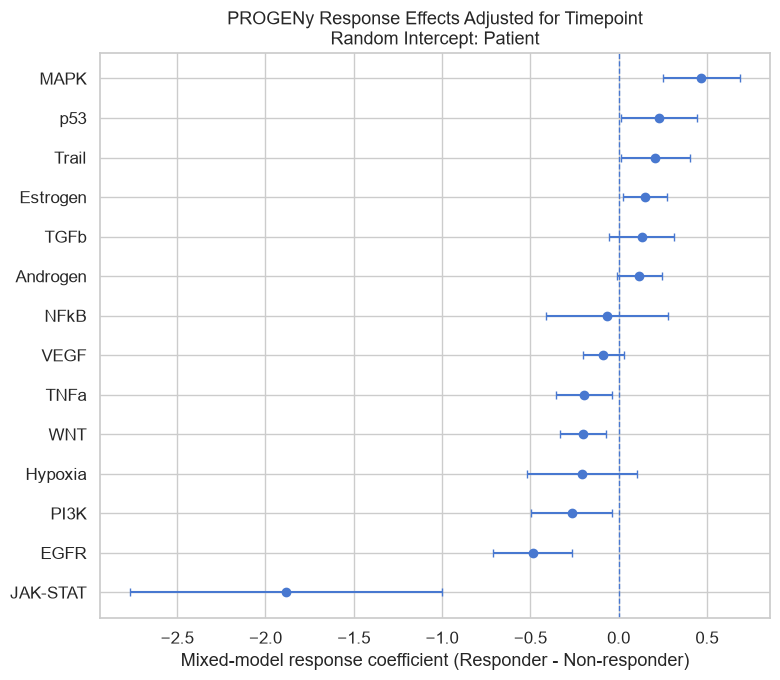

In [19]:
# Visualizing the response-effect estimates from the primary mixed-effects analysis (Only converged models).

plot_df = (mixed_results.loc[mixed_results['converged']].sort_values('beta_response_R_vs_NR').copy())
y = np.arange(len(plot_df))


fig, ax = plt.subplots(figsize=(8, 7))
ax.errorbar(plot_df['beta_response_R_vs_NR'],y,
            xerr=[plot_df['beta_response_R_vs_NR'] - plot_df['ci95_low'],plot_df['ci95_high'] - plot_df['beta_response_R_vs_NR']],
            fmt='o',capsize=3)

# Reference blue dotted line corresponding to no R vs NR difference
ax.axvline(0, linestyle='--', linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(plot_df['pathway'])

ax.set_xlabel('Mixed-model response coefficient (Responder - Non-responder)')
ax.set_ylabel('')
ax.set_title('PROGENy Response Effects Adjusted for Timepoint\n''Random Intercept: Patient')
plt.tight_layout()

plt.savefig(
    figures_dir / 'differential_pathways_mixed_model_coefficients.png',
    bbox_inches='tight'
)

plt.show()

**Comment:** The strongest response differences are observed for JAK-STAT, EGFR and MAPK. JAK-STAT and EGFR show higher activity in Non-responders, while MAPK shows higher activity in Responders.

## Volcano-style plot of the primary mixed-effects results

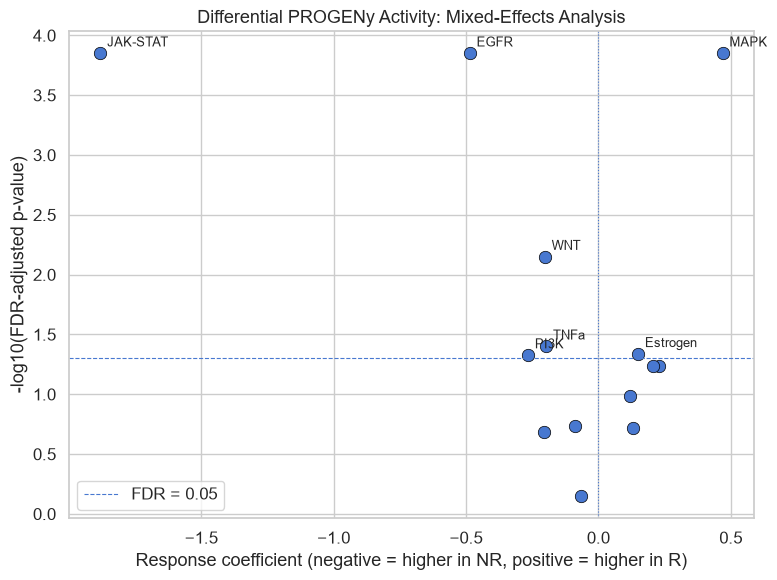

In [20]:
# Volcano-style visualization of the response effects from the converged mixed-effects models.

fig, ax = plt.subplots(figsize=(8, 6))
plot_df = mixed_results.loc[mixed_results['converged'] == True].copy()

# Transforming the FDR-adjusted p-values for visualization
plot_df['neg_log10_fdr'] = -np.log10(plot_df['p_fdr_bh_response'].clip(lower=1e-300))

ax.scatter( plot_df['beta_response_R_vs_NR'],plot_df['neg_log10_fdr'],s=80,edgecolor='black',linewidth=0.5)


# Label the pathways significant after BH-FDR correction
for _, row in plot_df.iterrows():
    if row['significant_fdr_0.05']:
        ax.annotate(row['pathway'],(row['beta_response_R_vs_NR'],row['neg_log10_fdr']),
                    textcoords='offset points',xytext=(5, 5),fontsize=9)


# FDR significance threshold and zero response-effect reference
ax.axhline(-np.log10(0.05),linestyle='--',linewidth=0.8,label='FDR = 0.05')
ax.axvline(0,linestyle=':',linewidth=0.8)
ax.set_xlabel('Response coefficient ''(negative = higher in NR, positive = higher in R)')
ax.set_ylabel('-log10(FDR-adjusted p-value)')
ax.set_title('Differential PROGENy Activity: Mixed-Effects Analysis')
ax.legend()
plt.tight_layout()

plt.savefig(figures_dir / 'differential_pathways_mixed_model_volcano.png',bbox_inches='tight')
plt.show()

**Comment:** 
Again it is shown that the JAK-STAT, EGFR and MAPK show the strongest response differences. JAK-STAT and EGFR are higher in Non-responders, while MAPK is higher in Responders. WNT, TNFa, PI3K and Estrogen also pass the FDR threshold, but with smaller effects.

## Sample-level boxplots for pathways significant in the primary mixed-effects analysis

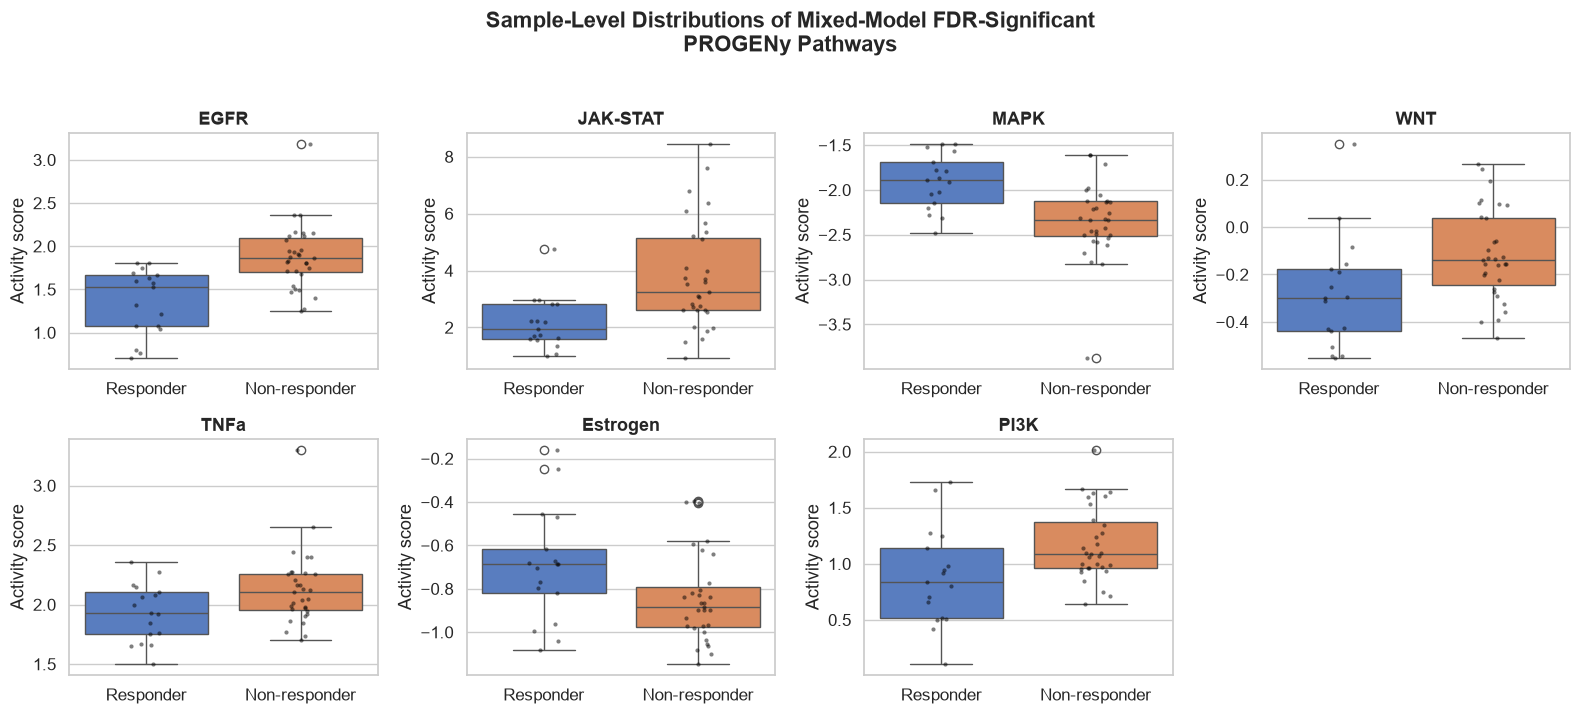

In [21]:
# Descriptive sample-level distributions for pathways that were significant in the converged primary mixed-effects models.

significant_pathways = mixed_results.loc[(mixed_results['converged'] == True) & (mixed_results['significant_fdr_0.05']),'pathway'].tolist()

if significant_pathways:
    plot_cols = [f'PROGENy_{p}' for p in significant_pathways]
    ncols = min(4, len(plot_cols))
    nrows = int(np.ceil(len(plot_cols) / ncols))


    fig, axes = plt.subplots(nrows,ncols,figsize=(ncols * 4, nrows * 3.5))
    axes = np.atleast_1d(axes).flatten()
    response_order = ['Responder', 'Non-responder']


    for i, col in enumerate(plot_cols):
        ax = axes[i]

        sns.boxplot(data=sample_df, x='response_label', y=col,
                    hue='response_label', order=response_order, hue_order=response_order,
                    legend=False,ax=ax)

        sns.stripplot( data=sample_df, x='response_label', y=col,
                      order=response_order, color='black',size=3,
                      alpha=0.5, ax=ax)

        ax.set_title(col.replace('PROGENy_', ''),fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('Activity score')


    # Hide unused subplot axes
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Sample-Level Distributions of Mixed-Model FDR-Significant\n' 'PROGENy Pathways', y=1.02, fontweight='bold')
    plt.tight_layout()
    plt.savefig(figures_dir / 'differential_pathways_mixed_significant_boxplots.png',bbox_inches='tight')
    plt.show()

## Descriptive heatmap of median pathway activity by response group

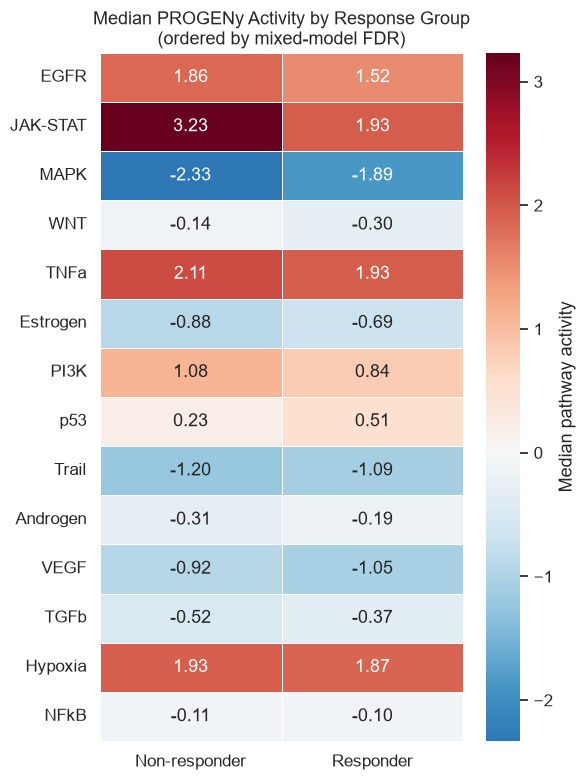

In [22]:
# Descriptive heatmap of median pathway activity by response group,
# ordered according to the FDR from the converged mixed-effects models.

median_by_response = (sample_df.groupby('response_label', observed=True)[pathway_cols].median().T)
median_by_response.index = median_by_response.index.str.replace('PROGENy_','',regex=False)
order = (mixed_results.loc[mixed_results['converged'] == True].sort_values('p_fdr_bh_response')['pathway'])
median_by_response = median_by_response.reindex(order)


# Plotting
fig, ax = plt.subplots(figsize=(6, 8))
sns.heatmap(median_by_response, cmap='RdBu_r',center=0,annot=True,fmt='.2f',linewidths=0.4,ax=ax,cbar_kws={'label': 'Median pathway activity'})
ax.set_title('Median PROGENy Activity by Response Group\n''(ordered by mixed-model FDR)')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(figures_dir / 'differential_pathways_median_heatmap.png',bbox_inches='tight')
plt.show()

**Comment:** Both the boxplots and the heatmap show the same general pathway pattern between Responders and Non-responders.

---
# Summary Table

In [23]:
# Primary mixed-effects analysis --> Final report table
# All pathways are retained
report_summary = mixed_results[['pathway','beta_response_R_vs_NR', 'ci95_low','ci95_high',
                                'p_value_response','p_fdr_bh_response','significant_fdr_0.05',
                                'direction','converged','model_qc']].copy()



report_summary = report_summary.rename(columns={'beta_response_R_vs_NR': 'Response coefficient (R-NR)',
                                                'ci95_low': '95% CI lower',
                                                'ci95_high': '95% CI upper',
                                                'p_value_response': 'P-value',
                                                'p_fdr_bh_response': 'FDR-adjusted P-value',
                                                'significant_fdr_0.05': 'Significant (FDR<0.05)',
                                                'direction': 'Direction',
                                                'converged': 'Model converged',
                                                'model_qc': 'Model QC'
                                                })


report_summary.to_csv(results_dir / 'differential_pathways_report_table.csv', index=False)
display(report_summary)

,pathway,Response coefficient (R-NR),95% CI lower,95% CI upper,P-value,FDR-adjusted P-value,Significant (FDR<0.05),Direction,Model converged,Model QC
0,EGFR,-0.486141,-0.709286,-0.262996,0.000020,0.000141,True,Higher in Non-responders,True,Converged
1,JAK-STAT,-1.881732,-2.765932,-0.997532,0.000030,0.000141,True,Higher in Non-responders,True,Converged
2,MAPK,0.468923,0.250819,0.687026,0.000025,0.000141,True,Higher in Responders,True,Converged
3,WNT,-0.202681,-0.331404,-0.073959,0.002028,0.007098,True,Higher in Non-responders,True,Converged
4,TNFa,-0.197728,-0.355816,-0.039640,0.014229,0.039842,True,Higher in Non-responders,True,Converged
5,Estrogen,0.149694,0.023835,0.275553,0.019746,0.046075,True,Higher in Responders,True,Converged
6,PI3K,-0.265903,-0.496135,-0.035671,0.023597,0.047194,True,Higher in Non-responders,True,Converged
7,p53,0.227655,0.013784,0.441525,0.036953,0.057482,False,Higher in Responders,True,Converged
8,Trail,0.207788,0.012696,0.402880,0.036842,0.057482,False,Higher in Responders,True,Converged
9,Androgen,0.118168,-0.011325,0.247662,0.073687,0.103162,False,Higher in Responders,True,Converged - random-effect variance near zero


In [24]:
task_figures_dir = figures_dir / "taskb_2_all_figures"
task_figures_dir.mkdir(parents=True, exist_ok=True)

moved = []
for png_file in list(figures_dir.glob("*.png")):  
    destination = task_figures_dir / png_file.name
    shutil.move(str(png_file), str(destination))
    moved.append(png_file.name)

print(f"Moved {len(moved)} figures into: {task_figures_dir}")
for name in sorted(moved):
    print(" -", name)

Moved 4 figures into: ..\figures\taskb_2_all_figures
 - differential_pathways_median_heatmap.png
 - differential_pathways_mixed_model_coefficients.png
 - differential_pathways_mixed_model_volcano.png
 - differential_pathways_mixed_significant_boxplots.png


# Summary of the Analysis

| Pathway      | Primary MixedLM | Sample-level MWU | Patient-level MWU | Main direction |
| ------------ | --------------- | ---------------- | ----------------- | -------------- |
| **EGFR**     | ✓               | ✓                | ✓                 | Higher in NR   |
| **JAK-STAT** | ✓               | ✓                | ✓                 | Higher in NR   |
| **PI3K**     | ✓               | ✓                | ✓                 | Higher in NR   |
| **MAPK**     | ✓               | ✓                | ✓                 | Higher in R    |
| **WNT**      | ✓               | ✓                | —                 | Higher in NR   |
| **TNFa**     | ✓               | —                | —                 | Higher in NR   |
| **Estrogen** | ✓               | —                | —                 | Higher in R    |
| **p53**      | —               | ✓                | ✓                 | Higher in R    |


Where: ✓ = FDR-significant; — = not FDR-significant.

Overall, EGFR, JAK-STAT, PI3K and MAPK show the most consistent response-associated differences across the different analyses.

**Worth mentioning:** PROGENy scores are estimated pathway activity scores. Therefore, they show differences in predicted pathway activity and not direct or causal effects of the pathways on treatment response.

---
# References

> [12]. Mann-Whitney U test (`scipy.stats.mannwhitneyu`): https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html </br>
> [13]. Benjamini-Hochberg FDR correction (`statsmodels.stats.multitest.multipletests`): https://www.statsmodels.org/stable/generated/statsmodels.stats.multitest.multipletests.html </br>
> [14]. Linear mixed-effects models (`statsmodels.regression.mixed_linear_model.MixedLM`): https://www.statsmodels.org/stable/generated/statsmodels.regression.mixed_linear_model.MixedLM.html </br>
> [15]. Rank-biserial correlation: Kerby, D. S. (2014). *The simple difference formula: An approach to teaching nonparametric correlation*. Comprehensive Psychology, 3, 11.IT.3.1.
